<a href="https://colab.research.google.com/github/amii-uwl-dba/northstar-analytics/blob/main/2_Python_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
base_url = "https://raw.githubusercontent.com/amii-uwl-dba/northstar-analytics/main/"

deliveries = pd.read_csv(base_url + "deliveries.csv")
complaints = pd.read_csv(base_url + "complaints.csv")
customers = pd.read_csv(base_url + "customers.csv")
drivers = pd.read_csv(base_url + "drivers.csv")
hubs = pd.read_csv(base_url + "hubs.csv")
incidents = pd.read_csv(base_url + "incidents.csv")
orders = pd.read_csv(base_url + "orders.csv")
vehicles = pd.read_csv(base_url + "vehicles.csv")
app_events = pd.read_csv(base_url + "app_events.csv")

In [3]:
deliveries.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22


In [4]:
complaints.head()

,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
0,CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
1,CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
2,CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41
3,CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44
4,CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18


In [5]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   delivery_id                    950 non-null    object 
 1   order_id                       950 non-null    object 
 2   driver_id                      950 non-null    object 
 3   vehicle_id                     950 non-null    object 
 4   hub_id                         950 non-null    object 
 5   dispatch_time                  950 non-null    object 
 6   delivery_completed_at          931 non-null    object 
 7   delivery_status                950 non-null    object 
 8   route_distance_km              950 non-null    float64
 9   manual_route_override_count    950 non-null    int64  
 10  proof_of_completion_missing    950 non-null    int64  
 11  customer_rating_post_delivery  936 non-null    float64
 12  fuel_or_charge_cost            950 non-null    flo

In [6]:
complaints.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   complaint_id         320 non-null    object 
 1   customer_id          320 non-null    object 
 2   order_id             320 non-null    object 
 3   complaint_type       320 non-null    object 
 4   channel              320 non-null    object 
 5   severity             320 non-null    object 
 6   created_at           320 non-null    object 
 7   status               320 non-null    object 
 8   resolution_days      320 non-null    int64  
 9   compensation_amount  304 non-null    float64
dtypes: float64(1), int64(1), object(8)
memory usage: 25.1+ KB


In [7]:
deliveries.isnull().sum()

,0
delivery_id,0
order_id,0
driver_id,0
vehicle_id,0
hub_id,0
dispatch_time,0
delivery_completed_at,19
delivery_status,0
route_distance_km,0
manual_route_override_count,0


In [8]:
complaints.isnull().sum()

,0
complaint_id,0
customer_id,0
order_id,0
complaint_type,0
channel,0
severity,0
created_at,0
status,0
resolution_days,0
compensation_amount,16


In [9]:
deliveries = deliveries.drop_duplicates()

complaints = complaints.drop_duplicates()

orders = orders.drop_duplicates()

In [10]:
deliveries["dispatch_time"] = pd.to_datetime(deliveries["dispatch_time"])

deliveries["delivery_completed_at"] = pd.to_datetime(deliveries["delivery_completed_at"])

deliveries["delivery_duration_minutes"] = (
    deliveries["delivery_completed_at"] -
    deliveries["dispatch_time"]
).dt.total_seconds() / 60

In [11]:
deliveries[["dispatch_time",
            "delivery_completed_at",
            "delivery_duration_minutes"]].head()

,dispatch_time,delivery_completed_at,delivery_duration_minutes
0,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,1328.998405
1,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,-66.000000
2,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,66.539446
3,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,1439.135062
4,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,242.568851


In [12]:
hub_delay = deliveries.groupby("hub_id")[
    "delivery_duration_minutes"
].mean()

hub_delay

,delivery_duration_minutes
hub_id,
H01,562.902086
H02,532.024348
H03,459.414852
H04,619.829453
H05,654.248030
H06,562.758006
H07,595.113258
H08,589.150707


In [13]:
deliveries["delivery_status"].value_counts()

,count
delivery_status,
OnTime,616
Delayed,202
Failed,132


In [14]:
complaints["complaint_type"].value_counts()

,count
complaint_type,
Delay,101
MissedPickup,64
AppIssue,53
DriverBehaviour,51
SupportExperience,20
Billing,16
Damage,15


In [15]:
complaints.groupby("severity")[
    "compensation_amount"
].mean()

,compensation_amount
severity,
High,38.847941
Low,9.056000
Medium,17.365120


In [16]:
orders.groupby("service_type")[
    "order_value"
].mean()

,order_value
service_type,
Business,92.245030
Medical,87.136187
Parcel,87.615649
Passenger,96.073636
Retail,90.013670


In [17]:
incidents["incident_type"].value_counts()

,count
incident_type,
ProofMissing,46
CustomerNoShow,44
RouteDeviation,43
VehicleFault,37
BatteryAlert,36
AppSyncError,31
TemperatureIssue,29
SafetyNearMiss,14


In [18]:
vehicles.groupby("vehicle_type")[
    "battery_health_pct"
].mean()

,battery_health_pct
vehicle_type,
CargoVan,73.383333
Diesel,70.563158
EV,82.124390
Hybrid,76.838462


In [19]:
deliveries.groupby("hub_id")[
    "manual_route_override_count"
].mean()

,manual_route_override_count
hub_id,
H01,1.029412
H02,0.915094
H03,0.890756
H04,0.874016
H05,0.947826
H06,0.913462
H07,1.052174
H08,1.109375


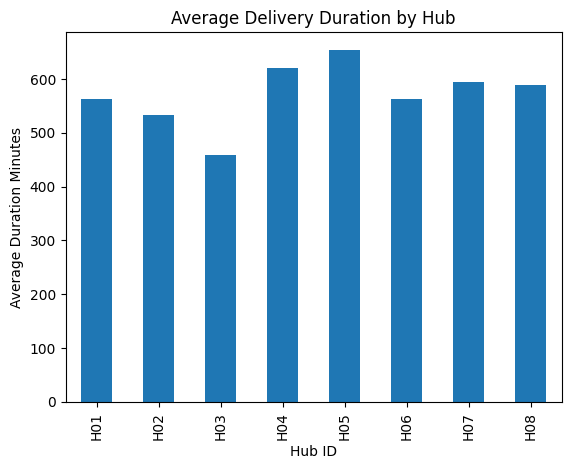

In [20]:
hub_delay.plot(kind="bar")

plt.title("Average Delivery Duration by Hub")
plt.xlabel("Hub ID")
plt.ylabel("Average Duration Minutes")

plt.show()

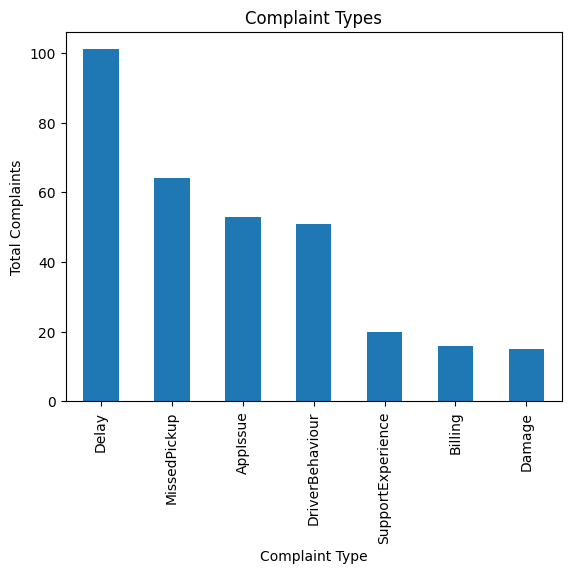

In [21]:
complaints["complaint_type"].value_counts().plot(kind="bar")

plt.title("Complaint Types")
plt.xlabel("Complaint Type")
plt.ylabel("Total Complaints")

plt.show()

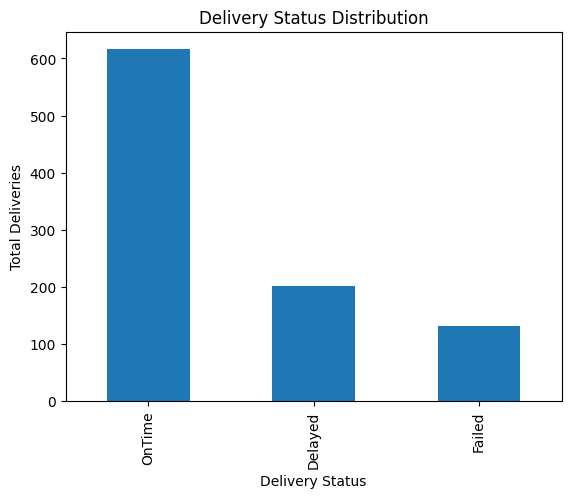

In [22]:
deliveries["delivery_status"].value_counts().plot(kind="bar")

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Total Deliveries")

plt.show()

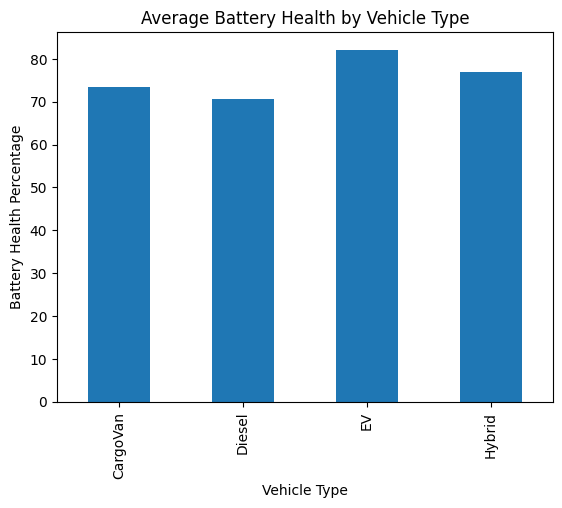

In [23]:
vehicles.groupby("vehicle_type")[
    "battery_health_pct"
].mean().plot(kind="bar")

plt.title("Average Battery Health by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Battery Health Percentage")

plt.show()

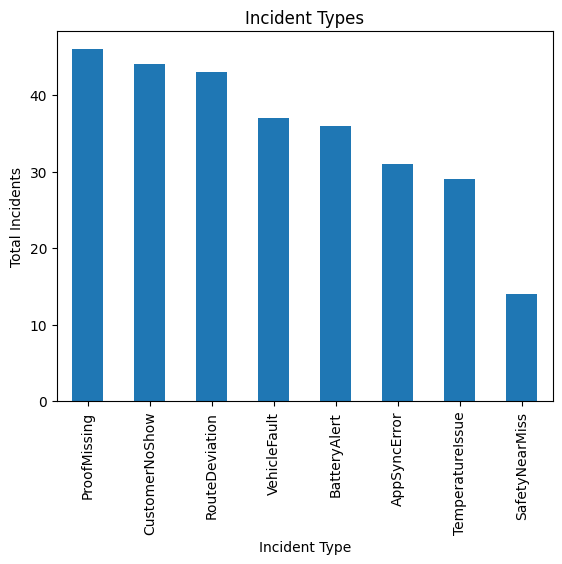

In [24]:
incidents["incident_type"].value_counts().plot(kind="bar")

plt.title("Incident Types")
plt.xlabel("Incident Type")
plt.ylabel("Total Incidents")

plt.show()

In [25]:
print("""
The Python analysis identified several operational issues within NorthStar.
Some hubs show longer delivery durations and higher manual route overrides,
suggesting route planning inefficiencies.
Complaint patterns indicate customer dissatisfaction in specific service areas,
while vehicle battery health and incidents may contribute to operational disruptions.
""")


The Python analysis identified several operational issues within NorthStar.
Some hubs show longer delivery durations and higher manual route overrides,
suggesting route planning inefficiencies.
Complaint patterns indicate customer dissatisfaction in specific service areas,
while vehicle battery health and incidents may contribute to operational disruptions.

